## Coursework 2 Group (text)

Group number: 29

Student names and k-numbers:
1. Kishan Bangsi Magar - K2545729
2. Pradeep Appasaheb Nayak - K2520606
3. Shweta Patankar - K2557766
4. Daniel Rolon Rodriguez - K2552225

# Load modules (code)

## Environment detection

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)
print("Colab push")

Running in Colab: False
Colab push


In [2]:
# Install dependencies
if IN_COLAB:
    import sys
    !git clone https://github.com/4yala/NotebooksDL
    %cd NotebooksDL
    !{sys.executable} -m pip install -r requirements.txt

#Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

#Data handling
import numpy as np
import random
import math

# Dataset
import medmnist
from medmnist import INFO
from medmnist.dataset import OrganSMNIST

# Pre-processing / Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
        ConfusionMatrixDisplay, balanced_accuracy_score,
        roc_auc_score, roc_curve, auc)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

2026-04-09 23:59:36.740842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 23:59:37.168762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 23:59:37.410894: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 23:59:37.504925: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 23:59:37.795620: I tensorflow/core/platform/cpu_feature_guar

# Load data

In [3]:
#Dataset selection
data_flag = "organsmnist"
info = INFO[data_flag]
data_root = "./data"

#Dataset loading
train_dataset = OrganSMNIST(split="train", download=True, size=224, root=data_root)
val_dataset   = OrganSMNIST(split="val", download=True, size=224, root=data_root)
test_dataset  = OrganSMNIST(split="test", download=True, size=224, root=data_root)

#NumPy formatting
X_train, y_train = train_dataset.imgs, train_dataset.labels
X_val, y_val     = val_dataset.imgs, val_dataset.labels
X_test, y_test   = test_dataset.imgs, test_dataset.labels

#Labelling
classes = np.unique(y_train)
num_classes = len(classes)
class_names = list(info["label"].values())


## Preprocess data

In [4]:
#Normalise data
X_train_normal = X_train / 255.0
X_val_normal   = X_val / 255.0
X_test_normal  = X_test / 255.0

#Flatten data
X_train_flat = X_train_normal.reshape(len(X_train_normal), -1)
X_val_flat   = X_val_normal.reshape(len(X_val_normal), -1)
X_test_flat  = X_test_normal.reshape(len(X_test_normal), -1)

# Initial Visualisation

## Basic observations

In [7]:
#Dataset shape checks
print("Train shape:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation shape:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest shape:")
print("X:", X_test.shape)
print("y:", y_test.shape)

#Label visualisation
print("\nNumber of classes:", len(info["label"]))
print("Class labels:")
for idx, name in info["label"].items():
    print(f"{idx}: {name}")

Train shape:
X: (13932, 224, 224)
y: (13932, 1)

Validation shape:
X: (2452, 224, 224)
y: (2452, 1)

Test shape:
X: (8827, 224, 224)
y: (8827, 1)

Number of classes: 11
Class labels:
0: bladder
1: femur-left
2: femur-right
3: heart
4: kidney-left
5: kidney-right
6: liver
7: lung-left
8: lung-right
9: pancreas
10: spleen


## Class balance observation

### Setup

In [ ]:
def get_class_counts(labels, num_classes):
    counts = np.zeros(num_classes)

    # labels often come as shape (N, 1)
    labels = np.squeeze(labels)

    for l in labels:
        counts[int(l)] += 1

    return counts

def plot_histogram(counts, title):
    plt.figure(figsize=(10,5))
    plt.bar(class_names, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Number of samples")
    plt.tight_layout()
    print("\n")
    plt.show()

def plot_pie(counts, title):
    plt.figure(figsize=(8,8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(counts)))
    plt.pie(counts, labels=class_names, autopct='%1.1f%%', colors=colours)
    plt.title(title)
    print("\n")
    plt.show()

### Train split

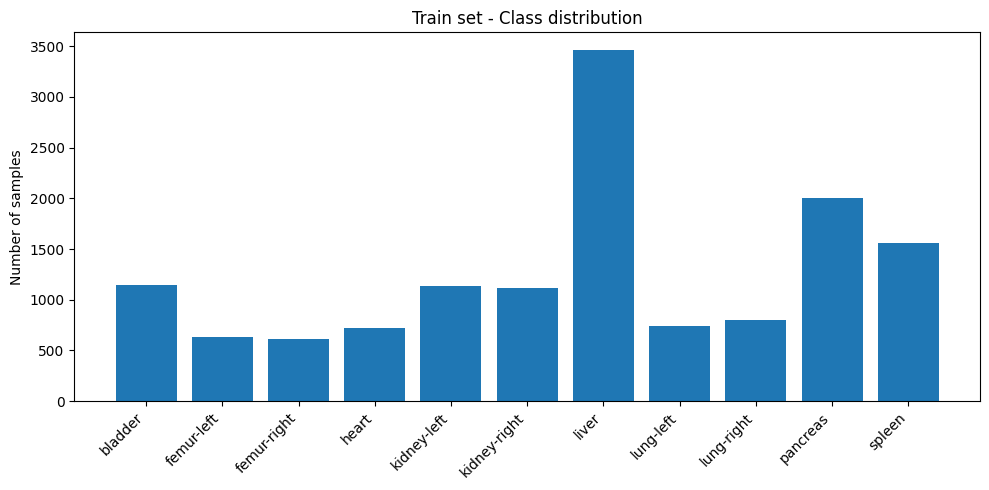

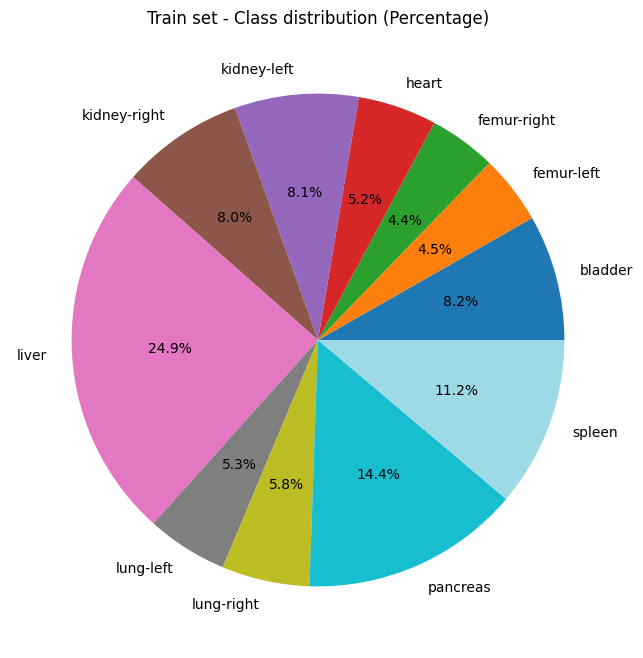

In [ ]:
train_counts = get_class_counts(y_train, num_classes)
plot_histogram(train_counts, "Train set - Class distribution")
plot_pie(train_counts, "Train set - Class distribution (Percentage)")

### Validation split


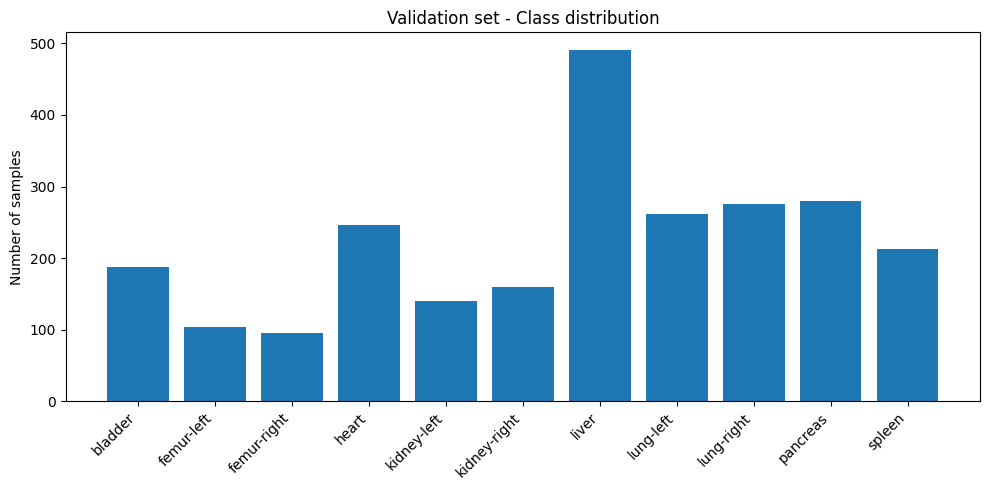

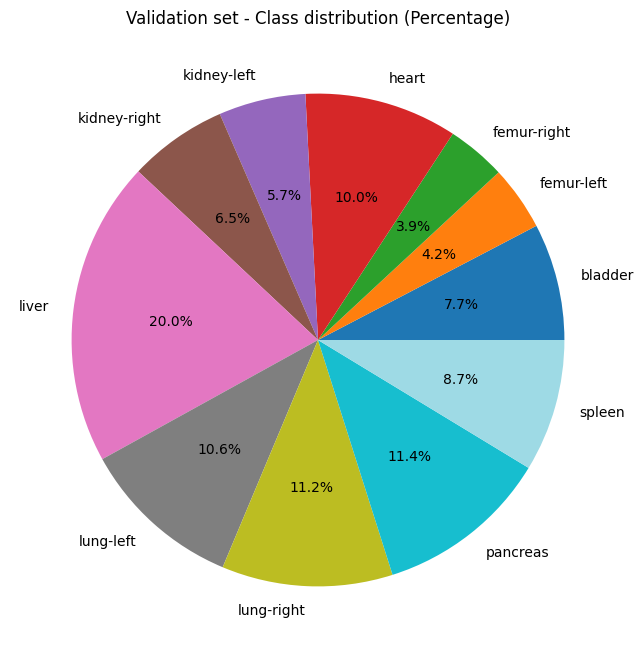

In [ ]:
val_counts   = get_class_counts(y_val, num_classes)
plot_histogram(val_counts, "Validation set - Class distribution")
plot_pie(val_counts, "Validation set - Class distribution (Percentage)")


### Test split

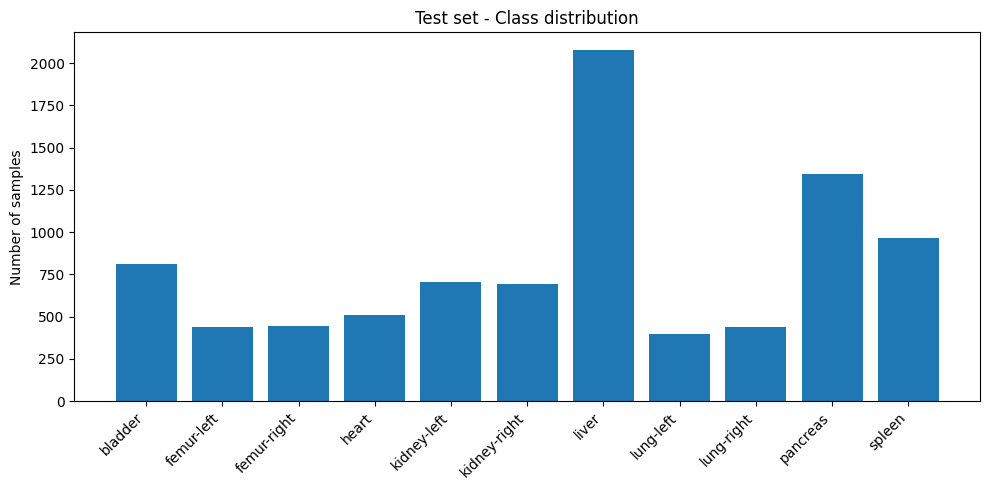

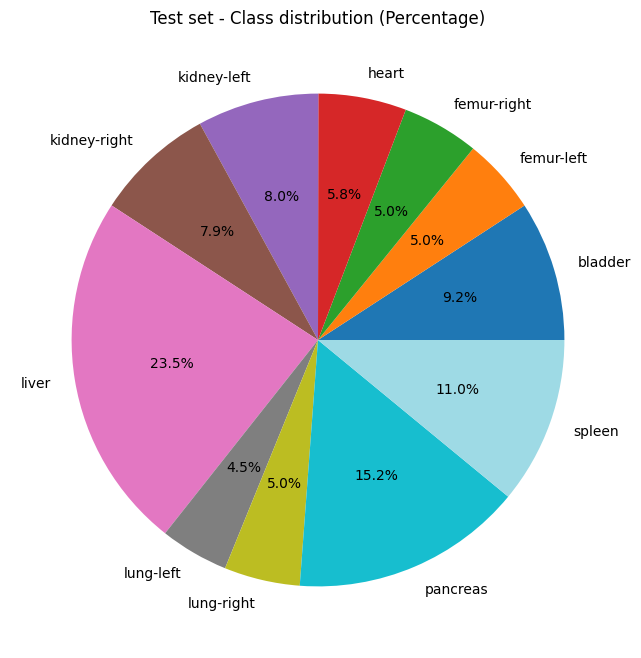

In [ ]:
test_counts  = get_class_counts(y_test, num_classes)
plot_histogram(test_counts, "Test set - Class distribution")
plot_pie(test_counts, "Test set - Class distribution (Percentage)")

### Split comparison

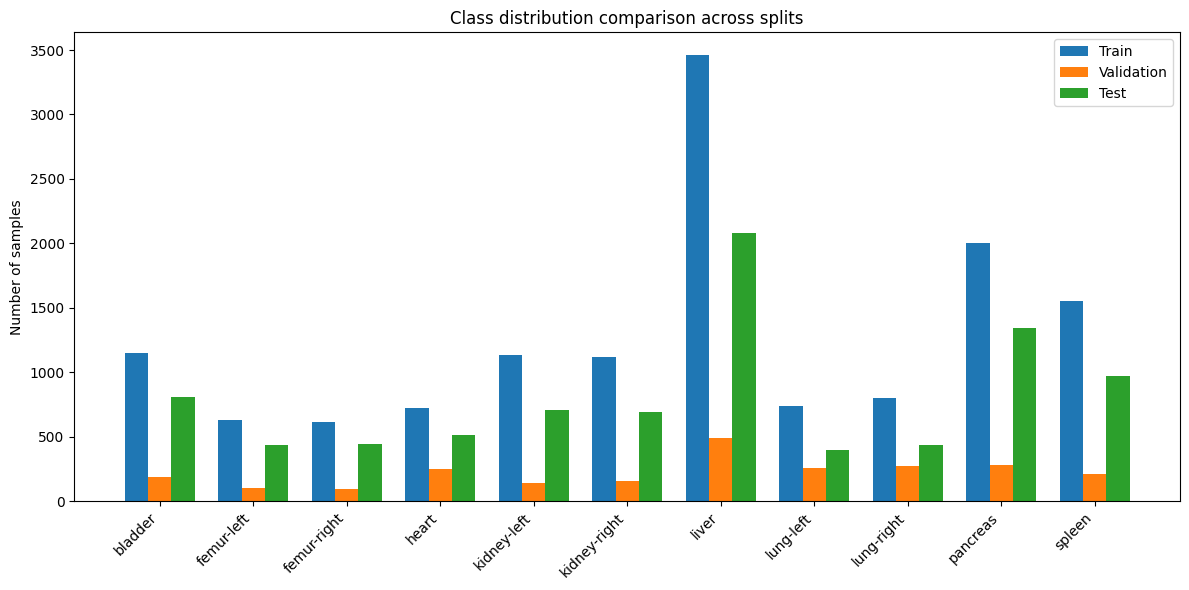

In [ ]:
x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, train_counts, width, label='Train')
plt.bar(x, val_counts, width, label='Validation')
plt.bar(x + width, test_counts, width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.title("Class distribution comparison across splits")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

## Sample visualisation

### Setup

In [ ]:
def show_images(images, labels, title, class_names, n=None):
    if n is None:
        n = len(images)

    cols = 3
    rows = math.ceil(n / cols)

    plt.figure(figsize=(6, 2 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_one_per_class(X, y, title):
    seen = {}
    images = []
    labels = []

    y = np.squeeze(y)

    for img, label in zip(X, y):
        label = int(label)

        if label not in seen:
            seen[label] = True
            images.append(img)
            labels.append(label)

        if len(seen) == len(class_names):
            break

    show_images(images, labels, title, class_names, n=len(class_names))

def show_samples_per_class(X, y, class_names, samples_per_class=5):
    y = np.squeeze(y)

    num_classes = len(class_names)

    for cls in range(num_classes):

        # get all images of this class
        idx = np.where(y == cls)[0]

        # handle edge case
        if len(idx) == 0:
            continue

        # randomly sample from this class
        chosen = np.random.choice(idx,
                                   size=min(samples_per_class, len(idx)),
                                   replace=False)

        images = X[chosen]
        labels = y[chosen]

        # plot grid
        cols = samples_per_class
        rows = 1

        plt.figure(figsize=(2 * cols, 2))

        for i in range(len(images)):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(class_names[int(labels[i])], fontsize=8)
            plt.axis('off')

        plt.suptitle(f"Class {cls}: {class_names[cls]}", fontsize=12)
        plt.tight_layout()
        plt.show()

### Random samples

/tmp/ipykernel_9642/2522428795.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[i])])


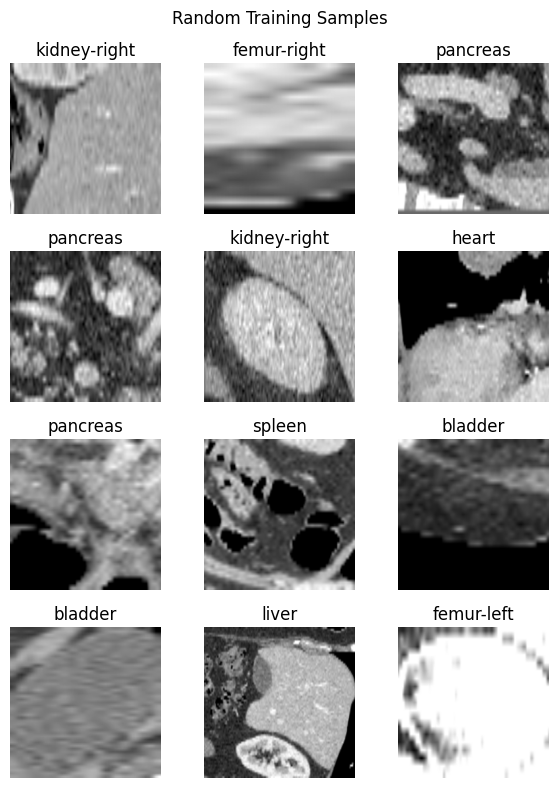

In [ ]:
idx = np.random.choice(len(X_train), 12, replace=False)

show_images(
    X_train[idx],
    y_train[idx],
    "Random Training Samples",
    class_names
)

### One per class

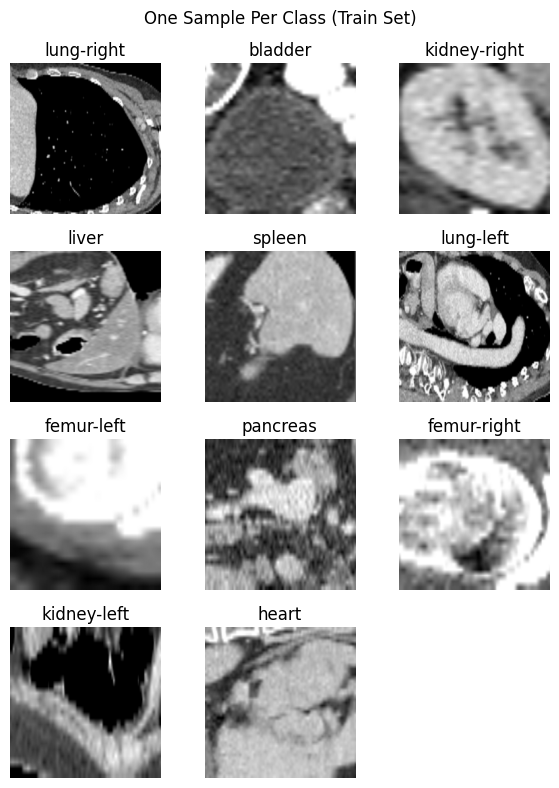

In [ ]:
show_one_per_class(X_train, y_train, "One Sample Per Class (Train Set)")

### Random per class

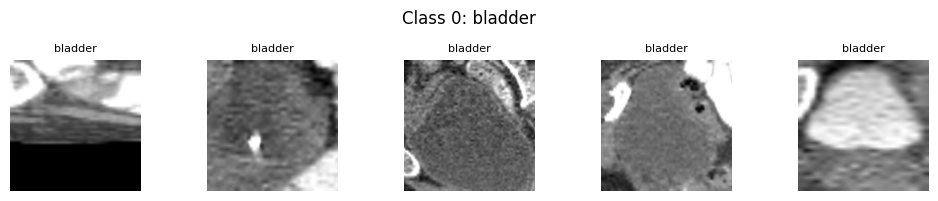

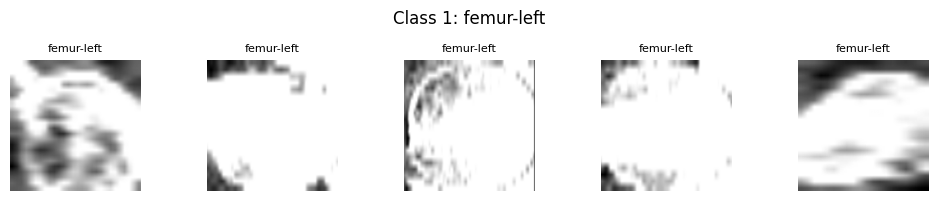

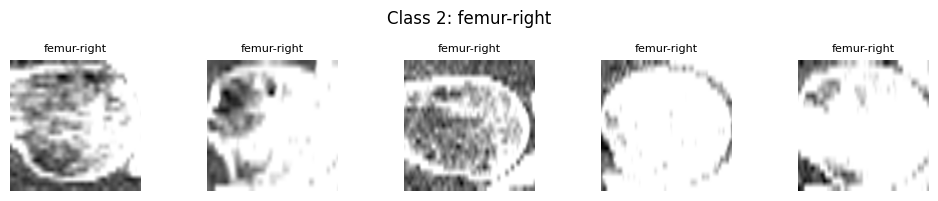

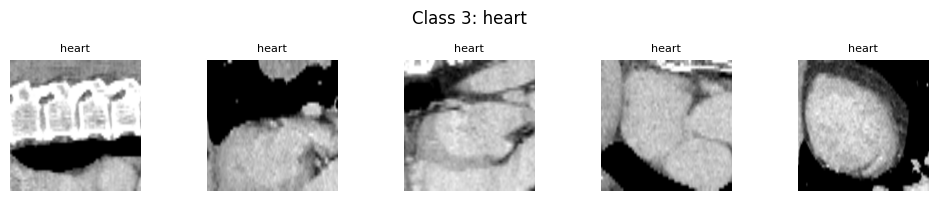

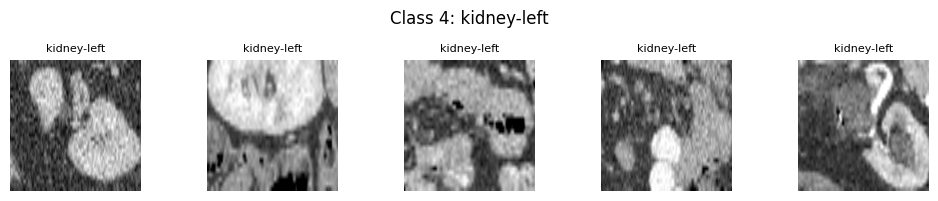

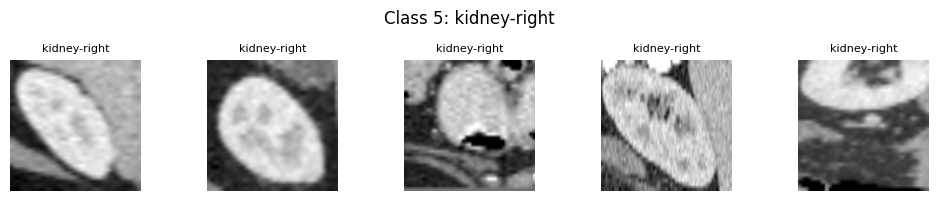

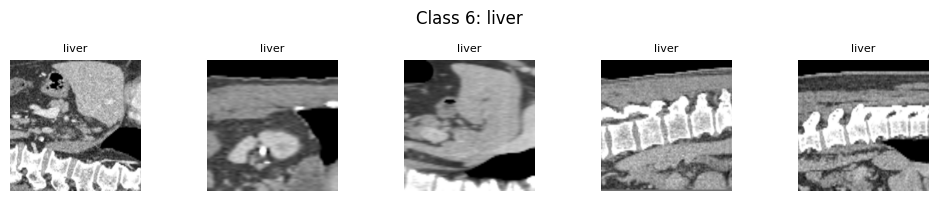

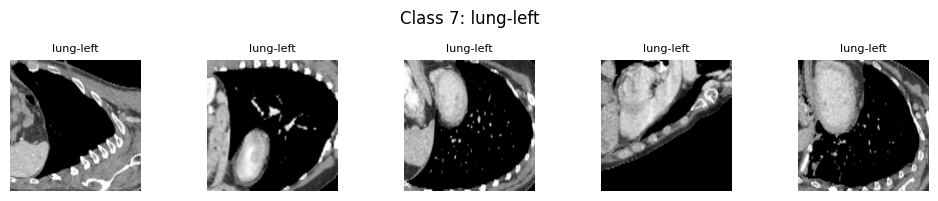

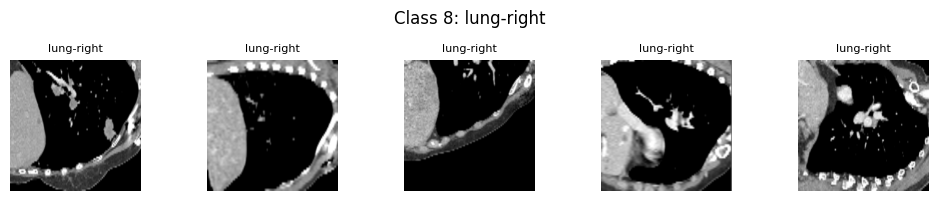

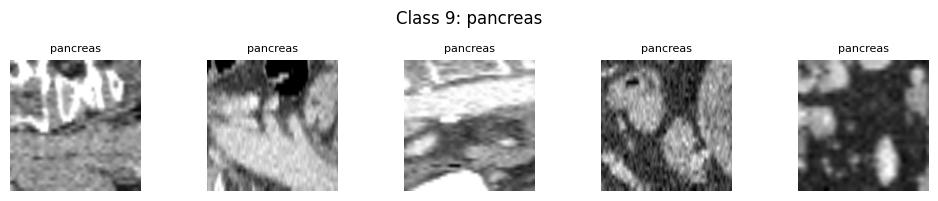

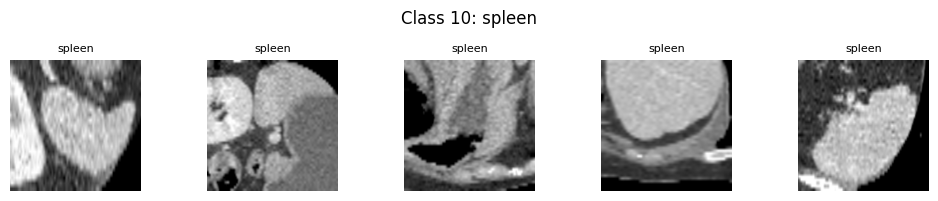

In [ ]:
show_samples_per_class(
    X_train,
    y_train,
    class_names,
    samples_per_class=5
)

# Model functions

## Evaluation

In [5]:
def evaluate_model(model, model_name, X_test, y_test, cmap):

    classes = np.arange(num_classes)

    #Mertics preparation-----------

    #Predict
    y_score = model.predict(X_test)
    y_pred = np.argmax(y_score, axis=1)

    #Basic metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    #Binarise for ROC
    y_test_bin = label_binarize(y_test,  classes=classes)

    #ROC AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_score, average='micro', multi_class='ovr')

    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Balanced accuracy', 'Macro ROC-AUC', 'Micro ROC-AUC'],
        'Score': [acc, balanced_acc, macro_auc, micro_auc]
    })

    #Metrics display
    print(f"\n{model_name} metrics:")
    display(metrics_df)

    print(f'\n{model_name} classification report:')
    print(f'\n {class_report}')
    
    #Confusion matrix---------------
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, xticks_rotation=45)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    #ROC curve-----------------
    plt.figure(figsize=(8,6))
    roc_data = {}
    for i in range(num_classes):
        fpr, tpr, _= roc_curve(y_test_bin[:, i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
        roc_data[i] = (fpr, tpr)
    
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'{model_name} ROC curves (OVR)')
    plt.legend(loc='lower right', fontsize='small')
    plt.show()

    #ROC values---------------
    #Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    micro_roc = (fpr_micro, tpr_micro)

    #Macro-average
    all_fpr = np.unique(np.concatenate([fpr for (fpr, _) in roc_data.values()]))
    mean_tpr = np.zeros_like(all_fpr)
    for (fpr, tpr) in roc_data.values():
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= num_classes
    macro_auc = (all_fpr, mean_tpr)


    #Return results----------
    return{
        'model_name': model_name,
        'metrics': {
            'Accuracy': acc,
            'Balanced accuracy': balanced_acc,
            'Macro ROC-AUC': macro_auc,
            'Micro ROC-AUC': micro_auc
        },
        'roc_data': roc_data,
        'micro_roc': micro_roc,
        'macro_roc': macro_auc
    }
        



# Q1 (Base NN model)

##  Model definition

In [ ]:
#Build
base_NN_model = Sequential([
    Input(shape=(X_train_flat.shape[1],)),
    Dense(100, activation='relu'),
    Dense(num_classes, activation='softmax')
])

#Compilation
base_NN_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1775752873.729713   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.729780   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.729792   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.937757   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775752873.937823   44577 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-09

## Model training

In [12]:
base_NN_history = base_NN_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775752900.091524   45901 service.cc:146] XLA service 0x7a87b08cc7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775752900.092123   45901 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-09 16:41:40.128461: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-09 16:41:40.339195: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

 34/436 [=>............................] - ETA: 1s - loss: 14.1509 - accuracy: 0.2206

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 7s 12ms/step - loss: 3.1686 - accuracy: 0.2802 - val_loss: 1.9979 - val_accuracy: 0.3055
Epoch 2/10
436/436 [==============================] - 2s 4ms/step - loss: 2.0801 - accuracy: 0.3056 - val_loss: 1.9360 - val_accuracy: 0.3083
Epoch 3/10
436/436 [==============================] - 2s 4ms/step - loss: 2.0136 - accuracy: 0.3053 - val_loss: 1.8941 - val_accuracy: 0.3087
Epoch 4/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9766 - accuracy: 0.3091 - val_loss: 1.9286 - val_accuracy: 0.3108
Epoch 5/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9576 - accuracy: 0.3100 - val_loss: 1.9063 - val_accuracy: 0.3108
Epoch 6/10
436/436 [==============================] - 2s 4ms/step - loss: 1.9411 - accuracy: 0.3103 - val_loss: 1.9680 - val_accuracy: 0.2940
Epoch 7/10
436/436 [==============================] - 1s 3ms/step - loss: 1.9357 - accuracy: 0.3109 - val_loss: 1.9525 - val_accuracy: 0.3002
Epoch 8/10
436/4

## Model evaluation

In [12]:
evaluate_model(base_NN_model, 'Base NN', X_test_flat, y_test, 'Blues')

NameError: name 'evaluate_model' is not defined

# Q2 (NN model improvements)

## Model 1 (Neuron and layer increase)

### Definition

In [ ]:
#Build
NN_model_1 = Sequential([
    #Input
    Input(shape=(X_train_flat.shape[1],)),
    
    #Hidden
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    #Output
    Dense(num_classes, activation='softmax')
])

#Compilation
NN_model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Training

In [11]:
NN_1_history = NN_model_1.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  6/436 [..............................] - ETA: 4s - loss: 39.6569 - accuracy: 0.1823  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 12s 23ms/step - loss: 3.1942 - accuracy: 0.3846 - val_loss: 1.3286 - val_accuracy: 0.5481
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.4811 - accuracy: 0.4931 - val_loss: 1.2664 - val_accuracy: 0.5677
Epoch 3/10
436/436 [==============================] - 1s 3ms/step - loss: 1.2931 - accuracy: 0.5416 - val_loss: 1.1938 - val_accuracy: 0.5624
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1594 - accuracy: 0.5891 - val_loss: 1.5575 - val_accuracy: 0.4715
Epoch 5/10
436/436 [==============================] - 2s 6ms/step - loss: 1.1136 - accuracy: 0.6029 - val_loss: 1.2778 - val_accuracy: 0.5706
Epoch 6/10
436/436 [==============================] - 2s 6ms/step - loss: 1.0496 - accuracy: 0.6212 - val_loss: 0.8986 - val_accuracy: 0.6937
Epoch 7/10
436/436 [==============================] - 2s 6ms/step - loss: 0.9824 - accuracy: 0.6415 - val_loss: 1.1238 - val_accuracy: 0.6358
Epoch 8/10
436/

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN ++(Neurons & layer) metrics:


,Metric,Score
0,Accuracy,0.516937
1,Balanced accuracy,0.460618
2,Macro ROC-AUC,0.876178
3,Micro ROC-AUC,0.894980



NN ++(Neurons & layer) classification report:

               precision    recall  f1-score   support

           0       0.38      0.32      0.35       811
           1       0.23      0.05      0.08       439
           2       0.44      0.46      0.45       445
           3       0.60      0.46      0.52       510
           4       0.28      0.47      0.35       704
           5       0.35      0.29      0.32       693
           6       0.74      0.83      0.78      2078
           7       0.68      0.67      0.68       397
           8       0.77      0.63      0.69       439
           9       0.40      0.49      0.44      1343
          10       0.52      0.40      0.45       968

    accuracy                           0.52      8827
   macro avg       0.49      0.46      0.47      8827
weighted avg       0.52      0.52      0.51      8827



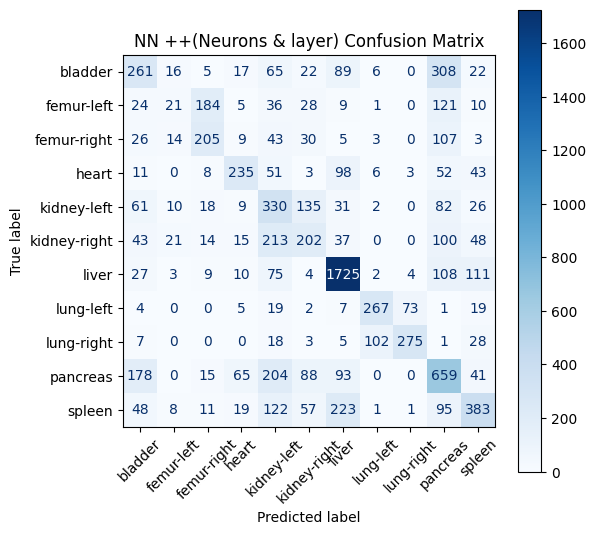

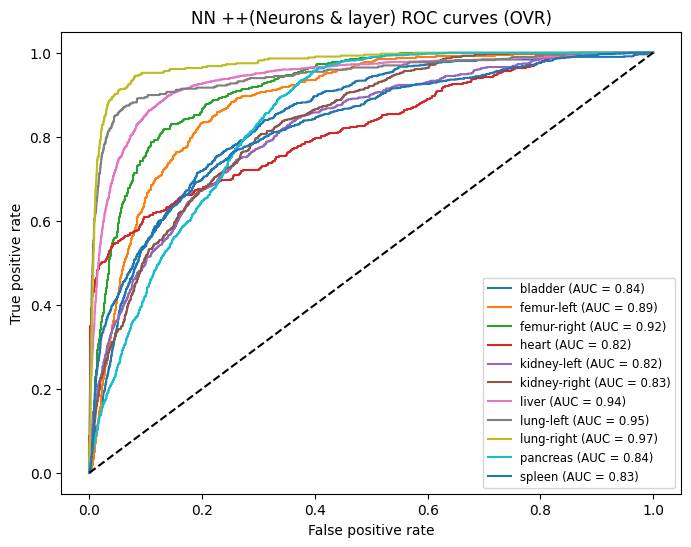

{'model_name': 'NN ++(Neurons & layer)',
 'metrics': {'Accuracy': 0.5169366715758469,
  'Balanced accuracy': 0.46061838078099054,
  'Macro ROC-AUC': (array([0.00000000e+00, 1.18623962e-04, 1.19217930e-04, ...,
          9.88772455e-01, 9.90768463e-01, 1.00000000e+00]),
   array([0.02405389, 0.02474086, 0.02536326, ..., 0.9998879 , 1.        ,
          1.        ])),
  'Micro ROC-AUC': 0.8949801695876589},
 'roc_data': {0: (array([0.00000000e+00, 1.24750499e-04, 1.24750499e-04, ...,
          9.90768463e-01, 9.90768463e-01, 1.00000000e+00]),
   array([0.        , 0.        , 0.00246609, ..., 0.99876695, 1.        ,
          1.        ])),
  1: (array([0.00000000e+00, 1.19217930e-04, 1.43061516e-03, 1.43061516e-03,
          2.98044826e-03, 2.98044826e-03, 3.69575584e-03, 3.69575584e-03,
          4.29184549e-03, 4.29184549e-03, 5.12637101e-03, 5.12637101e-03,
          5.24558894e-03, 5.24558894e-03, 5.60324273e-03, 5.60324273e-03,
          6.19933238e-03, 6.19933238e-03, 6.31855031e

In [12]:
evaluate_model(NN_model_1, 'NN ++(Neurons & layer)', X_test_flat, y_test, 'Blues')

## Model 2 (Class weight balancing)

### Definition

In [6]:
#Build
NN_model_2 = Sequential([
    #Input
    Input(shape=(X_train_flat.shape[1],)),
    
    #Hidden
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    #Output
    Dense(num_classes, activation='softmax')
])

#Compilation
NN_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Class weights
y_train_flat = y_train.flatten()

balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_flat
)

balanced_weights = dict(zip(classes, balanced_weights))

I0000 00:00:1775779210.627275  469015 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775779211.004843  469015 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775779211.004976  469015 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775779211.008974  469015 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775779211.009096  469015 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

### Training

In [10]:
NN_2_history = NN_model_2.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775770558.253017  323904 service.cc:146] XLA service 0x7aeb861fb2f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775770558.253597  323904 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-09 21:35:58.300732: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-09 21:35:58.545423: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

  1/436 [..............................] - ETA: 22:22 - loss: 2.2099 - accuracy: 0.0312

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 11s 17ms/step - loss: 3.7067 - accuracy: 0.3091 - val_loss: 1.2767 - val_accuracy: 0.5734
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.5206 - accuracy: 0.4287 - val_loss: 1.2097 - val_accuracy: 0.5493
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 1.4226 - accuracy: 0.4493 - val_loss: 1.1442 - val_accuracy: 0.5657
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 1.2479 - accuracy: 0.5103 - val_loss: 1.1335 - val_accuracy: 0.5803
Epoch 5/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1890 - accuracy: 0.5337 - val_loss: 1.1316 - val_accuracy: 0.6081
Epoch 6/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1380 - accuracy: 0.5507 - val_loss: 0.9938 - val_accuracy: 0.6444
Epoch 7/10
436/436 [==============================] - 3s 6ms/step - loss: 1.0952 - accuracy: 0.5668 - val_loss: 1.1326 - val_accuracy: 0.6097
Epoch 8/10
436/

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN + class weights) metrics:


,Metric,Score
0,Accuracy,0.450096
1,Balanced accuracy,0.439025
2,Macro ROC-AUC,0.866340
3,Micro ROC-AUC,0.875887



NN + class weights) classification report:

               precision    recall  f1-score   support

           0       0.43      0.19      0.26       811
           1       0.07      0.14      0.09       439
           2       0.20      0.76      0.32       445
           3       0.60      0.43      0.50       510
           4       0.44      0.19      0.27       704
           5       0.43      0.24      0.31       693
           6       0.76      0.69      0.73      2078
           7       0.68      0.79      0.73       397
           8       0.75      0.64      0.69       439
           9       0.33      0.35      0.34      1343
          10       0.52      0.42      0.46       968

    accuracy                           0.45      8827
   macro avg       0.48      0.44      0.43      8827
weighted avg       0.51      0.45      0.46      8827



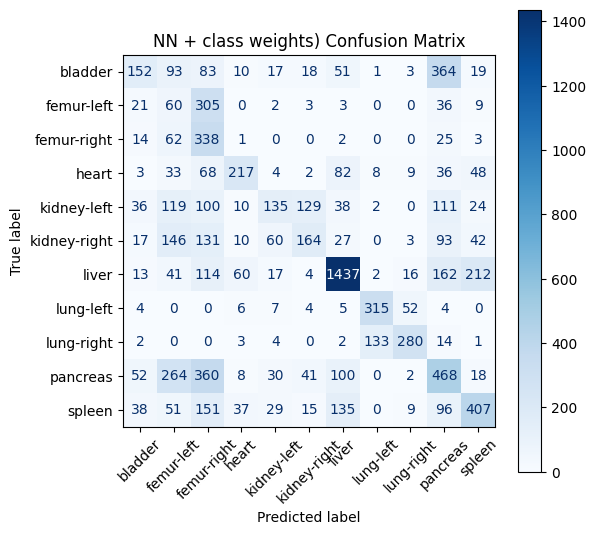

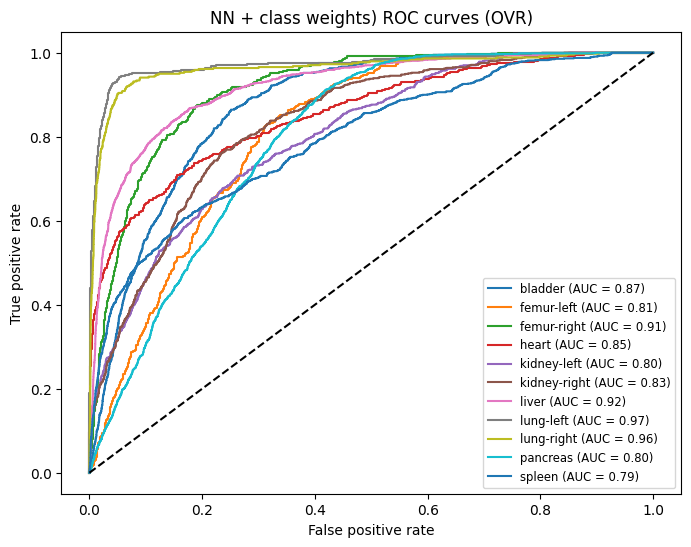

{'model_name': 'NN + class weights)',
 'metrics': {'Accuracy': 0.4500962954571202,
  'Balanced accuracy': 0.4390249159691941,
  'Macro ROC-AUC': (array([0.00000000e+00, 1.18623962e-04, 1.19217930e-04, ...,
          9.25054078e-01, 9.26326505e-01, 1.00000000e+00]),
   array([0.03514808, 0.04465097, 0.0461057 , ..., 0.99981217, 1.        ,
          1.        ])),
  'Micro ROC-AUC': 0.8758868356687373},
 'roc_data': {0: (array([0.00000000e+00, 1.24750499e-04, 7.48502994e-04, ...,
          8.02769461e-01, 8.02769461e-01, 1.00000000e+00]),
   array([0.        , 0.        , 0.        , ..., 0.99876695, 1.        ,
          1.        ])),
  1: (array([0.00000000e+00, 1.19217930e-04, 1.19217930e-04, 5.96089652e-04,
          5.96089652e-04, 9.53743443e-04, 9.53743443e-04, 1.43061516e-03,
          1.43061516e-03, 2.02670482e-03, 2.02670482e-03, 4.88793515e-03,
          4.88793515e-03, 5.60324273e-03, 5.60324273e-03, 7.39151168e-03,
          7.39151168e-03, 8.34525513e-03, 8.34525513e-03,

In [ ]:
evaluate_model(NN_model_2, 'NN + class weights', X_test_flat, y_test, 'Blues')

## Model 3 (+Dropout)

### Definition

In [6]:
#Build
NN_model_3 = Sequential([
    #Input
    Input(shape=(X_train_flat.shape[1],)),
    
    #Hidden
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),

    #Output
    Dense(num_classes, activation='softmax')
])

#Compilation
NN_model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1775774502.038466  390112 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775774502.545516  390112 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775774502.545558  390112 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775774502.553014  390112 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775774502.553082  390112 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

### Training

In [7]:
NN_3_history = NN_model_3.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  5/436 [..............................] - ETA: 15s - loss: 30.4317 - accuracy: 0.0812

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 9s 15ms/step - loss: 2.8013 - accuracy: 0.3077 - val_loss: 1.5855 - val_accuracy: 0.3699
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.7771 - accuracy: 0.3572 - val_loss: 1.5713 - val_accuracy: 0.4139
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 1.7406 - accuracy: 0.3735 - val_loss: 1.5796 - val_accuracy: 0.4152
Epoch 4/10
436/436 [==============================] - 1s 2ms/step - loss: 1.7148 - accuracy: 0.3749 - val_loss: 1.5853 - val_accuracy: 0.4017
Epoch 5/10
436/436 [==============================] - 3s 6ms/step - loss: 1.7445 - accuracy: 0.3597 - val_loss: 1.6501 - val_accuracy: 0.4082
Epoch 6/10
436/436 [==============================] - 3s 6ms/step - loss: 1.7601 - accuracy: 0.3536 - val_loss: 1.6399 - val_accuracy: 0.4160
Epoch 7/10
436/436 [==============================] - 2s 6ms/step - loss: 1.7411 - accuracy: 0.3646 - val_loss: 1.7189 - val_accuracy: 0.4237
Epoch 8/10
436/4

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN + dropout metrics:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Score
0,Accuracy,0.380197
1,Balanced accuracy,0.285443
2,Macro ROC-AUC,0.755700
3,Micro ROC-AUC,0.816649



NN + dropout classification report:

               precision    recall  f1-score   support

           0       0.34      0.01      0.02       811
           1       0.00      0.00      0.00       439
           2       0.69      0.02      0.04       445
           3       0.92      0.18      0.30       510
           4       0.00      0.00      0.00       704
           5       0.00      0.00      0.00       693
           6       0.56      0.72      0.63      2078
           7       0.62      0.71      0.66       397
           8       0.75      0.61      0.67       439
           9       0.23      0.89      0.37      1343
          10       0.00      0.00      0.00       968

    accuracy                           0.38      8827
   macro avg       0.37      0.29      0.24      8827
weighted avg       0.35      0.38      0.29      8827



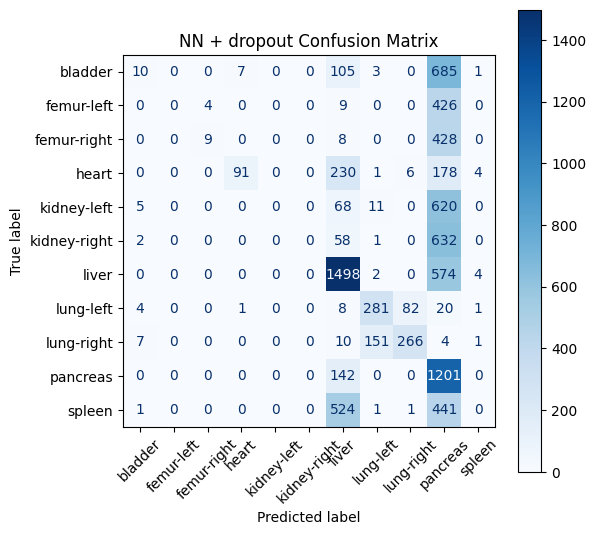

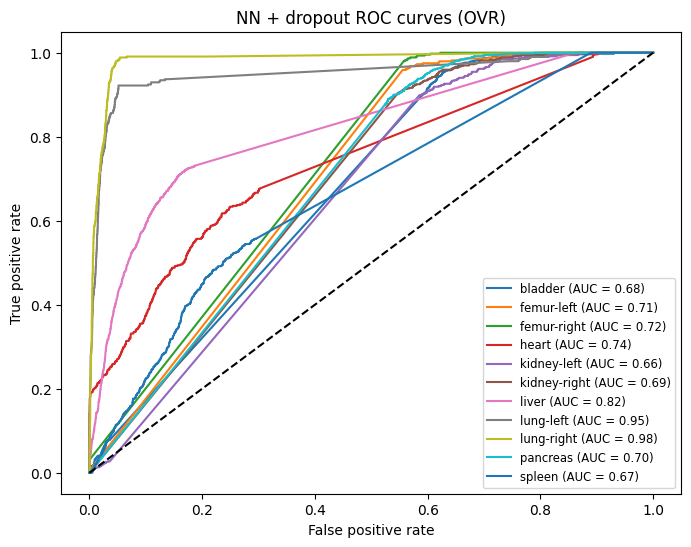

{'model_name': 'NN + dropout',
 'metrics': {'Accuracy': 0.3801971224651637,
  'Balanced accuracy': 0.28544269977664116,
  'Macro ROC-AUC': (array([0.00000000e+00, 1.18623962e-04, 1.19217930e-04, ...,
          9.90865955e-01, 9.91103203e-01, 1.00000000e+00]),
   array([0.02383713, 0.02406612, 0.02530861, ..., 1.        , 1.        ,
          1.        ])),
  'Micro ROC-AUC': 0.8166488100270227},
 'roc_data': {0: (array([0.00000000e+00, 0.00000000e+00, 4.99001996e-04, ...,
          9.31511976e-01, 9.31511976e-01, 1.00000000e+00]),
   array([0.        , 0.00123305, 0.00123305, ..., 0.99876695, 1.        ,
          1.        ])),
  1: (array([0.00000000e+00, 1.19217930e-04, 1.19217930e-04, 5.55674773e-01,
          5.58893658e-01, 5.59132093e-01, 5.60443491e-01, 5.60681927e-01,
          5.61397234e-01, 5.61397234e-01, 5.64735336e-01, 5.64735336e-01,
          5.68311874e-01, 5.68311874e-01, 5.69146400e-01, 5.69146400e-01,
          5.71173104e-01, 5.71411540e-01, 5.74988078e-01, 5.752

In [8]:
evaluate_model(NN_model_3, 'NN + dropout', X_test_flat, y_test, 'Blues')

## Model 4 --(Learning rate)

### Definition

In [11]:
#Build
NN_model_4 = Sequential([
    #Input
    Input(shape=(X_train_flat.shape[1],)),
    
    #Hidden
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    #Output
    Dense(num_classes, activation='softmax')
])

#Compilation
NN_model_4.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

### Training

In [12]:
NN_4_history = NN_model_4.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775775518.930915  406258 service.cc:146] XLA service 0x772f2a6a0000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775775518.931734  406258 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-09 22:58:38.985853: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-09 22:58:39.235671: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

  1/436 [..............................] - ETA: 19:06 - loss: 2.9346 - accuracy: 0.1250

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


436/436 [==============================] - 12s 21ms/step - loss: 2.7217 - accuracy: 0.3208 - val_loss: 1.3970 - val_accuracy: 0.5020
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.5485 - accuracy: 0.4326 - val_loss: 1.3118 - val_accuracy: 0.5200
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 1.3704 - accuracy: 0.4828 - val_loss: 1.3684 - val_accuracy: 0.5281
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 1.2113 - accuracy: 0.5334 - val_loss: 1.1641 - val_accuracy: 0.5763
Epoch 5/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1454 - accuracy: 0.5564 - val_loss: 1.2275 - val_accuracy: 0.6003
Epoch 6/10
436/436 [==============================] - 1s 2ms/step - loss: 1.0967 - accuracy: 0.5759 - val_loss: 1.5493 - val_accuracy: 0.4992
Epoch 7/10
436/436 [==============================] - 2s 6ms/step - loss: 1.0446 - accuracy: 0.5937 - val_loss: 1.0931 - val_accuracy: 0.6436
Epoch 8/10
436/

### Evaluation

276/276 [==============================] - 1s 2ms/step

NN + class weights metrics:


,Metric,Score
0,Accuracy,0.515577
1,Balanced accuracy,0.499828
2,Macro ROC-AUC,0.895266
3,Micro ROC-AUC,0.900360



NN + class weights classification report:

               precision    recall  f1-score   support

           0       0.43      0.58      0.50       811
           1       0.26      0.39      0.31       439
           2       0.31      0.42      0.36       445
           3       0.57      0.56      0.57       510
           4       0.35      0.41      0.38       704
           5       0.35      0.39      0.37       693
           6       0.70      0.80      0.75      2078
           7       0.65      0.82      0.72       397
           8       0.82      0.55      0.66       439
           9       0.52      0.24      0.33      1343
          10       0.55      0.34      0.42       968

    accuracy                           0.52      8827
   macro avg       0.50      0.50      0.49      8827
weighted avg       0.53      0.52      0.51      8827



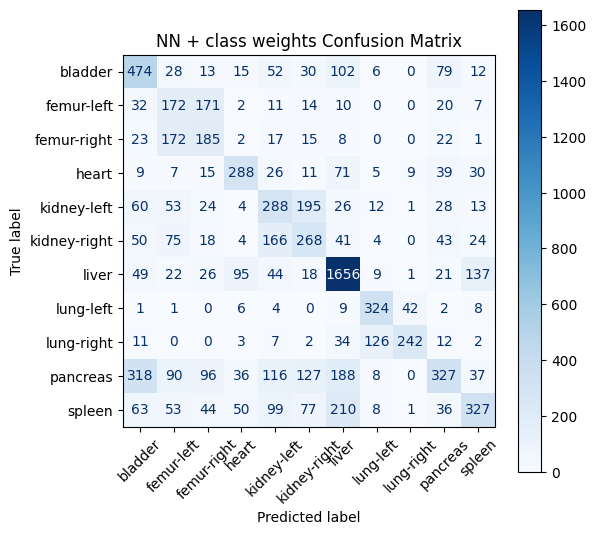

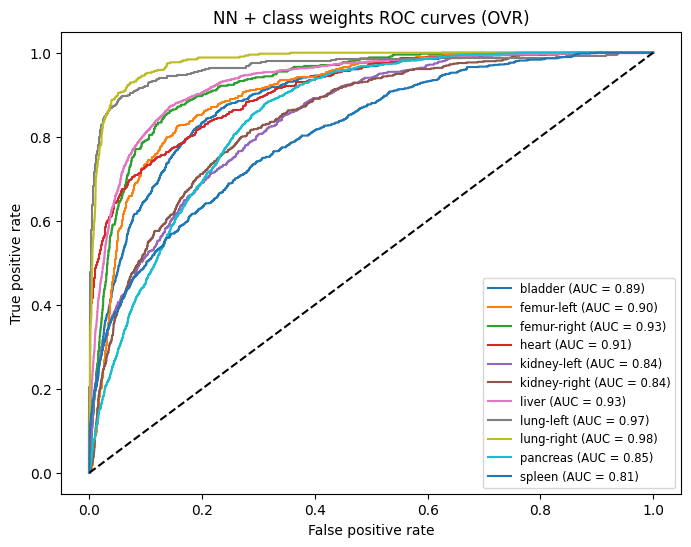

{'model_name': 'NN + class weights',
 'metrics': {'Accuracy': 0.5155772062988557,
  'Balanced accuracy': 0.4998275643199119,
  'Macro ROC-AUC': (array([0.00000000e+00, 1.18623962e-04, 1.19217930e-04, ...,
          9.35943060e-01, 9.38552788e-01, 1.00000000e+00]),
   array([0.03566207, 0.03996701, 0.03996907, ..., 0.99977101, 1.        ,
          1.        ])),
  'Micro ROC-AUC': 0.9003603242669417},
 'roc_data': {0: (array([0.00000000e+00, 0.00000000e+00, 2.49500998e-04, ...,
          8.63023952e-01, 8.63023952e-01, 1.00000000e+00]),
   array([0.        , 0.00123305, 0.00123305, ..., 0.99876695, 1.        ,
          1.        ])),
  1: (array([0.00000000e+00, 1.19217930e-04, 5.96089652e-04, 5.96089652e-04,
          1.43061516e-03, 1.43061516e-03, 3.33810205e-03, 3.33810205e-03,
          4.05340963e-03, 4.05340963e-03, 4.76871722e-03, 4.76871722e-03,
          4.88793515e-03, 4.88793515e-03, 5.48402480e-03, 5.48402480e-03,
          5.60324273e-03, 5.60324273e-03, 5.72246066e-03, 

In [13]:
evaluate_model(NN_model_4, 'NN + class weights', X_test_flat, y_test, 'Blues')

## Model 5 (Depth increase)

### Definition

In [7]:
#Build
NN_model_5 = Sequential([
    #Input
    Input(shape=(X_train_flat.shape[1],)),
    
    #Hidden
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    #Output
    Dense(num_classes, activation='softmax')
])

#Compilation
NN_model_5.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

### Training

In [8]:
NN_5_history = NN_model_5.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32,
    class_weight= balanced_weights
)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775779229.997048  470940 service.cc:146] XLA service 0x74e8ec3d8390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775779229.997404  470940 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0
2026-04-10 00:00:30.031595: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 00:00:30.300842: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91900
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

436/436 [==============================] - 12s 19ms/step - loss: 2.3062 - accuracy: 0.3214 - val_loss: 1.3019 - val_accuracy: 0.5179
Epoch 2/10
436/436 [==============================] - 3s 6ms/step - loss: 1.5772 - accuracy: 0.4225 - val_loss: 1.3705 - val_accuracy: 0.4898
Epoch 3/10
436/436 [==============================] - 3s 6ms/step - loss: 1.3150 - accuracy: 0.4897 - val_loss: 1.0649 - val_accuracy: 0.6130
Epoch 4/10
436/436 [==============================] - 3s 6ms/step - loss: 1.2002 - accuracy: 0.5362 - val_loss: 1.2035 - val_accuracy: 0.5600
Epoch 5/10
436/436 [==============================] - 3s 6ms/step - loss: 1.1481 - accuracy: 0.5561 - val_loss: 1.1507 - val_accuracy: 0.5926
Epoch 6/10
436/436 [==============================] - 3s 6ms/step - loss: 1.0590 - accuracy: 0.5930 - val_loss: 0.9516 - val_accuracy: 0.6815
Epoch 7/10
436/436 [==============================] - 3s 6ms/step - loss: 1.0247 - accuracy: 0.6012 - val_loss: 0.8788 - val_accuracy: 0.6872
Epoch 8/10
436/

### Evaluation

276/276 [==============================] - 1s 3ms/step

NN + final depth metrics:


,Metric,Score
0,Accuracy,0.474114
1,Balanced accuracy,0.492723
2,Macro ROC-AUC,0.881075
3,Micro ROC-AUC,0.883456



NN + final depth classification report:

               precision    recall  f1-score   support

           0       0.30      0.71      0.42       811
           1       0.30      0.35      0.32       439
           2       0.30      0.40      0.34       445
           3       0.58      0.54      0.56       510
           4       0.37      0.43      0.39       704
           5       0.53      0.18      0.27       693
           6       0.86      0.56      0.68      2078
           7       0.67      0.82      0.74       397
           8       0.81      0.70      0.75       439
           9       0.51      0.19      0.27      1343
          10       0.35      0.55      0.43       968

    accuracy                           0.47      8827
   macro avg       0.51      0.49      0.47      8827
weighted avg       0.55      0.47      0.48      8827



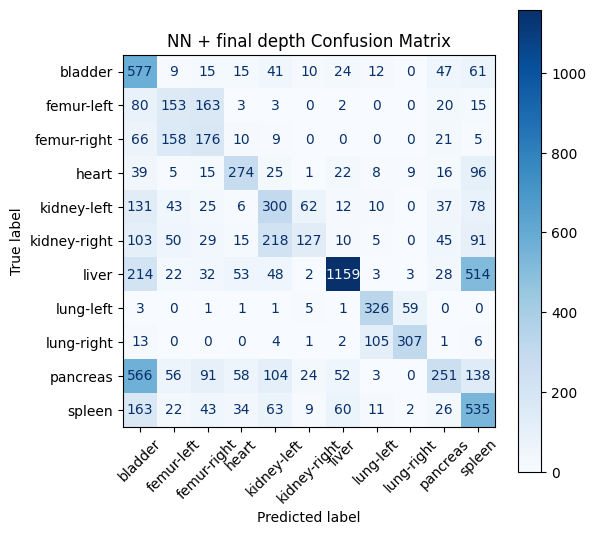

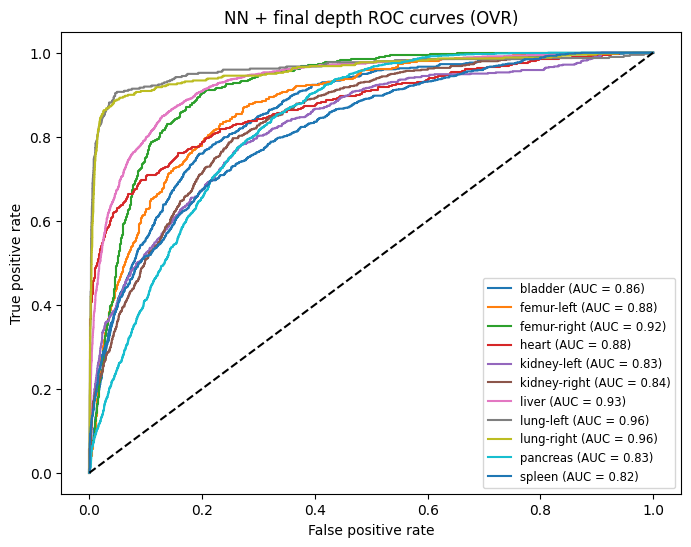

{'model_name': 'NN + final depth',
 'metrics': {'Accuracy': 0.47411351535062873,
  'Balanced accuracy': 0.4927226243845472,
  'Macro ROC-AUC': (array([0.00000000e+00, 1.19303269e-04, 1.20235662e-04, ...,
          9.83867141e-01, 9.93119810e-01, 1.00000000e+00]),
   array([0.00904395, 0.01389706, 0.02658776, ..., 0.99977101, 1.        ,
          1.        ])),
  'Micro ROC-AUC': 0.8834558001612225},
 'roc_data': {0: (array([0.        , 0.        , 0.        , ..., 0.96432136, 0.96432136,
          1.        ]),
   array([0.        , 0.00123305, 0.00246609, ..., 0.99876695, 1.        ,
          1.        ])),
  1: (array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.96089652e-04,
          5.96089652e-04, 8.34525513e-04, 8.34525513e-04, 9.53743443e-04,
          9.53743443e-04, 1.66905103e-03, 1.66905103e-03, 1.78826896e-03,
          1.78826896e-03, 2.26514068e-03, 2.26514068e-03, 2.62279447e-03,
          2.62279447e-03, 2.74201240e-03, 2.74201240e-03, 2.86123033e-03,
         

In [10]:
evaluate_model(NN_model_5, 'NN + final depth', X_test_flat, y_test, 'Blues')

# Q3

In [ ]:
# add code for Q3

## Q4

In [ ]:
# add code for Q4

In [ ]:
# add discussion for Q4

## Q5

In [ ]:
# add code for Q5

In [ ]:
# add discussion for Q5

## Q6

In [ ]:
# add code for Q6

In [ ]:
# add discussion for Q6

## Q7

In [ ]:
# add code for Q7

In [ ]:
# add discussion for Q7

# References (text)

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).